In [69]:
# Step 1: Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Optional: Plot settings
%matplotlib inline
sns.set(style="whitegrid")


In [71]:
# Step 2: Load and Inspect the Dataset (with full path)

df = pd.read_csv("/Users/janvibagani/Downloads/Merged0430.csv")

# Show dataset info
print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# Preview first few rows
df.head()


Dataset loaded successfully!
Shape of dataset: (2823353, 27)

Column names: ['Accident_Index', 'Accident_Severity', 'Accident_Severity3Category', 'Accident_Severity2Category', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Month', 'Year', 'Day_of_Week', 'WeekdayEnd', 'Time', 'Hour', 'Light_Conditions', 'Weather_Conditions', 'Wind', 'Precipitation', 'PrecipitationNumeric', 'RoadSurfaceCategorical', 'RoadSurfaceNumeric', 'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area', 'Vehicle_Reference', 'Vehicle_Type', 'Sex_of_Driver', '1st_Point_of_Impact']

Data types:
 Accident_Index                 object
Accident_Severity               int64
Accident_Severity3Category     object
Accident_Severity2Category     object
Number_of_Vehicles              int64
Number_of_Casualties            int64
Date                           object
Month                           int64
Year                            int64
Day_of_Week                    object
WeekdayEnd                     object
Time     

,Accident_Index,Accident_Severity,Accident_Severity3Category,Accident_Severity2Category,Number_of_Vehicles,Number_of_Casualties,Date,Month,Year,Day_of_Week,...,PrecipitationNumeric,RoadSurfaceCategorical,RoadSurfaceNumeric,Road_Type,Speed_limit,Urban_or_Rural_Area,Vehicle_Reference,Vehicle_Type,Sex_of_Driver,1st_Point_of_Impact
0,200501BS00001,2,Serious,Serious,1,1,2005-01-04,1,2005,Tue,...,3,Wet,2,TwoWayNonSeparated,30,Urban,1,2.0,Female,Front
1,200501BS00002,1,Slight,Slight,1,1,2005-01-05,1,2005,Wed,...,1,Dry,1,TwoWaySeparated,30,Urban,1,3.0,Male,NearSide
2,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,1,3.0,Male,NearSide
3,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,1,Dry,1,TwoWayNonSeparated,30,Urban,2,2.0,Male,OffSide
4,200501BS00004,1,Slight,Slight,1,1,2005-01-07,1,2005,Fri,...,1,Dry,1,TwoWayNonSeparated,30,Urban,1,2.0,Female,Front


In [73]:
# Step 3: Define Independent Variables (X) and Target Variable (y)

# We'll predict Accident_Severity
y = df["Accident_Severity"]

# Drop columns that should not be features
X = df.drop(columns=["Accident_Severity", "Accident_Index", "Date", "Time"])

# Confirm shape
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (2823353, 23)
y shape: (2823353,)


In [75]:
# Step 4: Set global variable for reproducibility
global RANDOM_STATE
RANDOM_STATE = 42

# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)

# Confirm shapes
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (2117514, 23)
Test set: (705839, 23)


In [77]:
# Use one-hot encoding for categorical columns
X_encoded = pd.get_dummies(X)

print("Encoding complete")
print("New shape of X:", X_encoded.shape)


Encoding complete
New shape of X: (2823353, 57)


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=RANDOM_STATE
)


In [81]:
# Step 5: Train a Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize model with global random state
model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Train model on training data
model_dt.fit(X_train, y_train)

# Predict on test data
y_pred_dt = model_dt.predict(X_test)

# Evaluate model accuracy
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {round(accuracy_dt * 100, 2)}%")


Decision Tree Accuracy: 100.0%


In [84]:
# Step 1: Check correlation of all columns with Accident_Severity
df_corr = df.copy()

# Convert object columns to numeric using label encoding for this analysis only
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Check correlation with target
correlations = df_corr.corr(numeric_only=True)['Accident_Severity'].sort_values(ascending=False)

print("Correlation with Accident_Severity:")
print(correlations)


Correlation with Accident_Severity:
Accident_Severity             1.000000
Number_of_Casualties          0.105531
Speed_limit                   0.094281
Light_Conditions              0.068916
Sex_of_Driver                 0.061531
1st_Point_of_Impact           0.049308
WeekdayEnd                    0.036859
Road_Type                     0.033305
Accident_Index                0.008187
Date                          0.004914
Year                          0.004672
Month                         0.002613
Time                          0.001389
Hour                          0.000639
Wind                         -0.002433
RoadSurfaceCategorical       -0.007340
Day_of_Week                  -0.007991
Vehicle_Reference            -0.009386
RoadSurfaceNumeric           -0.009894
Number_of_Vehicles           -0.012686
Precipitation                -0.020220
PrecipitationNumeric         -0.020220
Weather_Conditions           -0.021350
Vehicle_Type                 -0.033326
Urban_or_Rural_Area         

In [86]:
# A. Redefine y and fix X by removing leaking columns
y = df["Accident_Severity"]

X = df.drop(columns=[
    "Accident_Severity",
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time"
])


In [88]:
# B. Encode all object-type columns
X_encoded = pd.get_dummies(X)
print("Encoding complete")
print("X_encoded shape:", X_encoded.shape)

Encoding complete
X_encoded shape: (2823353, 52)


In [90]:
# C. Split and train again after fixing leakage

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=RANDOM_STATE
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy (after fixing leakage): {round(accuracy_dt * 100, 2)}%")


Decision Tree Accuracy (after fixing leakage): 78.59%


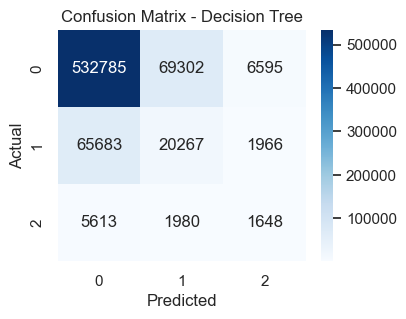

In [92]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 6: Confusion Matrix
cf_matrix = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(4, 3))
sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()


In [94]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred_dt)

# Define class labels (adjust if needed)
labels = ['Slight', 'Serious', 'Fatal']

# Convert to DataFrame for better readability
cf_df = pd.DataFrame(cf_matrix, index=[f'Actual: {label}' for label in labels],
                                  columns=[f'Predicted: {label}' for label in labels])

# Display as table
cf_df


,Predicted: Slight,Predicted: Serious,Predicted: Fatal
Actual: Slight,532785,69302,6595
Actual: Serious,65683,20267,1966
Actual: Fatal,5613,1980,1648


In [96]:
# Feature Importance from Decision Tree

importances = model_dt.feature_importances_
feature_names = X_encoded.columns

# Combine into a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display top features
importance_df.head(10)


,Feature,Importance
2,Month,0.175896
4,Hour,0.171486
3,Year,0.160287
0,Number_of_Vehicles,0.038201
8,Speed_limit,0.038055
1,Number_of_Casualties,0.028059
10,Vehicle_Type,0.025488
11,Day_of_Week_Fri,0.022574
9,Vehicle_Reference,0.021668
17,Day_of_Week_Wed,0.021384


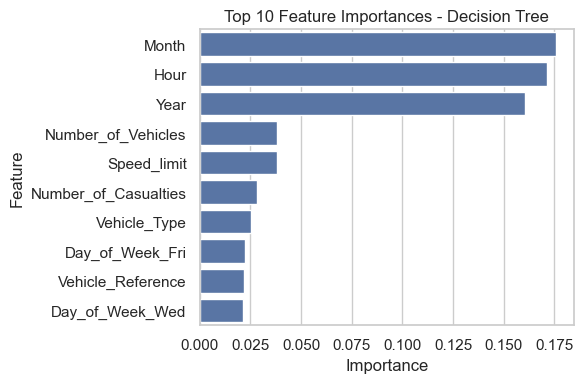

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()

Decision Tree Accuracy: 78.59%

Confusion Matrix:
                 Predicted: Slight  Predicted: Serious  Predicted: Fatal
Actual: Slight              532785               69302              6595
Actual: Serious              65683               20267              1966
Actual: Fatal                 5613                1980              1648


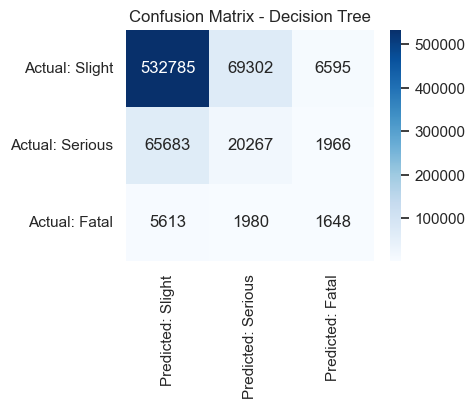


Top 10 Important Features:
                 Feature  Importance
2                  Month    0.175896
4                   Hour    0.171486
3                   Year    0.160287
0     Number_of_Vehicles    0.038201
8            Speed_limit    0.038055
1   Number_of_Casualties    0.028059
10          Vehicle_Type    0.025488
11       Day_of_Week_Fri    0.022574
9      Vehicle_Reference    0.021668
17       Day_of_Week_Wed    0.021384


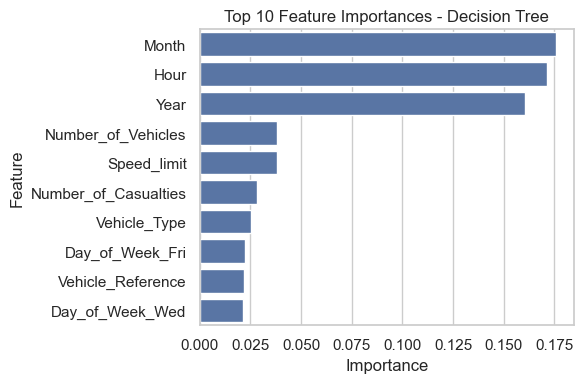

In [100]:
# 1. Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Data
df = pd.read_csv("/Users/janvibagani/Downloads/Merged0430.csv")

# 3. Define y and Clean X
y = df["Accident_Severity"]
X = df.drop(columns=[
    "Accident_Severity",
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time"
])

# 4. Encode Categorical Variables
X_encoded = pd.get_dummies(X)

# 5. Split Data
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=RANDOM_STATE
)

# 6. Train Decision Tree
model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)

# 7. Predict & Accuracy
y_pred_dt = model_dt.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {round(accuracy_dt * 100, 2)}%")

# 8. Confusion Matrix
cf_matrix = confusion_matrix(y_test, y_pred_dt)
labels = ['Slight', 'Serious', 'Fatal']
cf_df = pd.DataFrame(cf_matrix, index=[f'Actual: {l}' for l in labels],
                                 columns=[f'Predicted: {l}' for l in labels])
print("\nConfusion Matrix:")
print(cf_df)

plt.figure(figsize=(4,3))
sns.heatmap(cf_df, annot=True, cmap="Blues", fmt='g')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

# 9. Feature Importance
importances = model_dt.feature_importances_
feature_names = X_encoded.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances - Decision Tree")
plt.tight_layout()
plt.show()


In [102]:
# Clone the original DataFrame
df_no_time = df.copy()

# Define new target and features
y2 = df_no_time["Accident_Severity"]
X2 = df_no_time.drop(columns=[
    "Accident_Severity",
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time",
    "Month",
    "Year"
])

# Encode categorical features
X2_encoded = pd.get_dummies(X2)

# Train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded, y2, test_size=0.25, random_state=RANDOM_STATE
)

# Train Decision Tree
model_dt_2 = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt_2.fit(X2_train, y2_train)

# Evaluate accuracy
y2_pred = model_dt_2.predict(X2_test)
accuracy_dt_2 = accuracy_score(y2_test, y2_pred)
print(f"Decision Tree Accuracy (without Date, Month, Year): {round(accuracy_dt_2 * 100, 2)}%")

# Top features after removing time
importance_df_2 = pd.DataFrame({
    'Feature': X2_encoded.columns,
    'Importance': model_dt_2.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🔝 Top 10 Features Without Date/Month/Year:")
print(importance_df_2.head(10))


Decision Tree Accuracy (without Date, Month, Year): 83.27%

🔝 Top 10 Features Without Date/Month/Year:
                 Feature  Importance
2                   Hour    0.227291
6            Speed_limit    0.071669
0     Number_of_Vehicles    0.070121
1   Number_of_Casualties    0.050598
8           Vehicle_Type    0.045714
7      Vehicle_Reference    0.042807
3       Light_Conditions    0.035775
9        Day_of_Week_Fri    0.025488
13       Day_of_Week_Thu    0.025108
15       Day_of_Week_Wed    0.024881


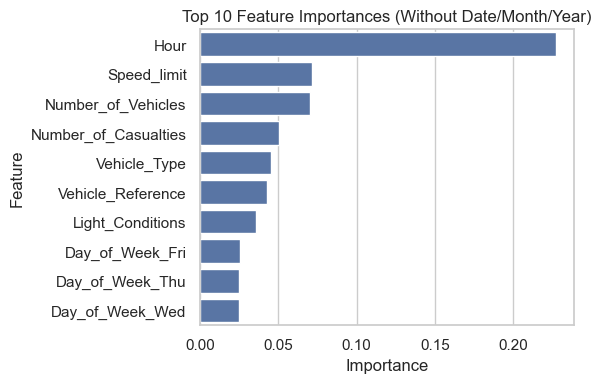

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top 10 important features for second decision tree model
plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df_2.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances (Without Date/Month/Year)")
plt.tight_layout()
plt.show()


In [106]:
# Step 1: Define threshold for importance
low_importance_threshold = 0.01  # You can lower this if needed

# Step 2: Get list of low-importance features
low_importance_features = importance_df_2[importance_df_2["Importance"] < low_importance_threshold]["Feature"].tolist()

print(f"Removing {len(low_importance_features)} low-importance features:")
print(low_importance_features)

# Step 3: Drop those features from X2_encoded
X2_filtered = X2_encoded.drop(columns=low_importance_features)

# Step 4: Re-split and retrain
X2_train_f, X2_test_f, y2_train_f, y2_test_f = train_test_split(
    X2_filtered, y2, test_size=0.25, random_state=RANDOM_STATE
)

model_dt_filtered = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt_filtered.fit(X2_train_f, y2_train_f)

y2_pred_f = model_dt_filtered.predict(X2_test_f)
accuracy_filtered = accuracy_score(y2_test_f, y2_pred_f)

print(f"Accuracy After Removing Low-Importance Features: {round(accuracy_filtered * 100, 2)}%")


Removing 24 low-importance features:
['Urban_or_Rural_Area_Urban', 'WeekdayEnd_Weekday', 'Weather_Conditions_Fine No Wind', 'WeekdayEnd_Weekend', 'Weather_Conditions_Rain No Wind', '1st_Point_of_Impact_NoImpact', 'PrecipitationNumeric', 'Road_Type_Roundabout', 'Precipitation_Fine', 'Precipitation_Rain', 'Road_Type_OneWay', 'Weather_Conditions_Fine High Wind', 'Wind_HighWind', 'Wind_Normal', 'Road_Type_SlipRoad', 'RoadSurfaceCategorical_Frost', 'Weather_Conditions_Rain High Wind', 'Weather_Conditions_Fog', 'Precipitation_Fog', 'RoadSurfaceCategorical_Snow', 'Weather_Conditions_Snow No Wind', 'Precipitation_Snow', 'RoadSurfaceCategorical_Flood', 'Weather_Conditions_Snow High Wind']
Accuracy After Removing Low-Importance Features: 83.7%


In [107]:
# Recalculate and display top features after removing low-importance ones
importance_df_filtered = pd.DataFrame({
    'Feature': X2_filtered.columns,
    'Importance': model_dt_filtered.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Show top 10
print("Top 10 Most Important Features (After Cleanup):")
print(importance_df_filtered.head(10))


Top 10 Most Important Features (After Cleanup):
                      Feature  Importance
2                        Hour    0.238760
5                 Speed_limit    0.078031
0          Number_of_Vehicles    0.076151
1        Number_of_Casualties    0.056315
6           Vehicle_Reference    0.051654
7                Vehicle_Type    0.047927
3            Light_Conditions    0.039048
19  Urban_or_Rural_Area_Rural    0.029192
8             Day_of_Week_Fri    0.027260
4          RoadSurfaceNumeric    0.027222


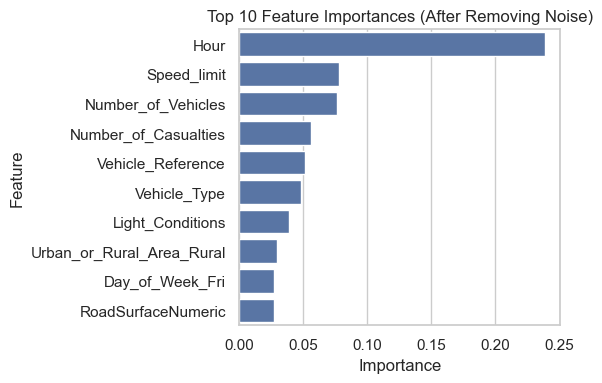

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df_filtered.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances (After Removing Noise)")
plt.tight_layout()
plt.show()


In [112]:
# Step 1: Remove columns before encoding
X2 = df.drop(columns=[
    "Accident_Severity",
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time",
    "Month",
    "Year",
    "Vehicle_Reference"  # remove this ID column
])

y2 = df["Accident_Severity"]

# Step 2: Encode categorical variables
X2_encoded = pd.get_dummies(X2)

# Step 3: Drop all Day_of_Week_* dummy variables
day_of_week_cols = [col for col in X2_encoded.columns if col.startswith("Day_of_Week_")]
X2_encoded_clean = X2_encoded.drop(columns=day_of_week_cols)

print(f"Removed {len(day_of_week_cols)} Day_of_Week columns:")
print(day_of_week_cols)

# Step 4: Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X2_encoded_clean, y2, test_size=0.25, random_state=RANDOM_STATE
)

# Step 5: Train model
model_dt_clean_c = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt_clean_c.fit(X_train_c, y_train_c)

# Step 6: Evaluate
y_pred_c = model_dt_clean_c.predict(X_test_c)
accuracy_c = accuracy_score(y_test_c, y_pred_c)
print(f"\n Accuracy after removing Vehicle_Reference and Day_of_Week: {round(accuracy_c * 100, 2)}%")


Removed 7 Day_of_Week columns:
['Day_of_Week_Fri', 'Day_of_Week_Mon', 'Day_of_Week_Sat', 'Day_of_Week_Sun', 'Day_of_Week_Thu', 'Day_of_Week_Tue', 'Day_of_Week_Wed']

 Accuracy after removing Vehicle_Reference and Day_of_Week: 85.15%


In [114]:
# Final feature importance
importance_df_final = pd.DataFrame({
    'Feature': X2_encoded_clean.columns,
    'Importance': model_dt_clean_c.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Final Top 10 Important Features:")
print(importance_df_final.head(10))


Final Top 10 Important Features:
                         Feature  Importance
2                           Hour    0.235253
0             Number_of_Vehicles    0.096462
6                    Speed_limit    0.094482
1           Number_of_Casualties    0.073417
7                   Vehicle_Type    0.066217
3               Light_Conditions    0.044553
9             WeekdayEnd_Weekend    0.027325
8             WeekdayEnd_Weekday    0.027089
33     Urban_or_Rural_Area_Rural    0.025225
31  Road_Type_TwoWayNonSeparated    0.022736


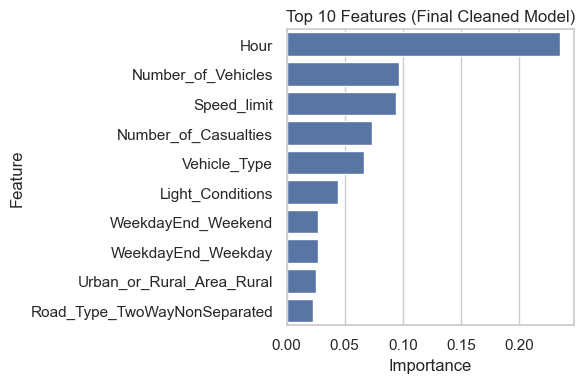

In [116]:
plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df_final.head(10), x='Importance', y='Feature')
plt.title("Top 10 Features (Final Cleaned Model)")
plt.tight_layout()
plt.show()


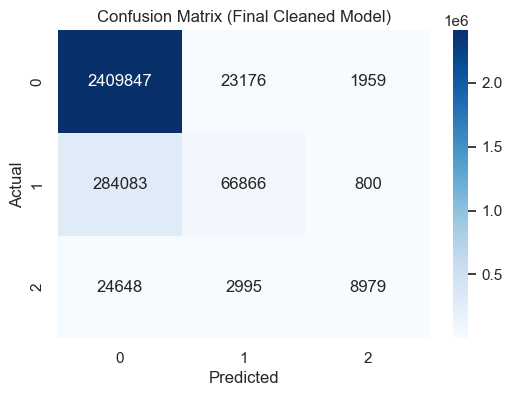

Classification Report (Final Cleaned Model):
              precision    recall  f1-score   support

           1       0.89      0.99      0.94   2434982
           2       0.72      0.19      0.30    351749
           3       0.76      0.25      0.37     36622

    accuracy                           0.88   2823353
   macro avg       0.79      0.47      0.54   2823353
weighted avg       0.86      0.88      0.85   2823353

Accuracy: 0.8804


In [124]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Predict using the cleaned model
y_pred_clean = model_dt_clean_c.predict(X2_encoded_clean)

# Confusion Matrix
cm_clean = confusion_matrix(y, y_pred_clean)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Final Cleaned Model)")
plt.show()

# Classification Report & Accuracy
print("Classification Report (Final Cleaned Model):")
print(classification_report(y, y_pred_clean))
print("Accuracy:", round(accuracy_score(y, y_pred_clean), 4))


In [128]:
from sklearn.metrics import classification_report, accuracy_score

# Predict using the cleaned model
y_pred_clean = model_dt_clean_c.predict(X2_encoded_clean)

# Print the classification report
print("Classification Report (Final Cleaned Model):")
print(classification_report(y, y_pred_clean))

# Print accuracy as percentage (like the screenshot)
accuracy = accuracy_score(y, y_pred_clean)
print("Accuracy: {:.4f}".format(accuracy))        # Decimal format
print("Accuracy: {:.2f}%".format(accuracy * 100)) # Percentage format


Classification Report (Final Cleaned Model):
              precision    recall  f1-score   support

           1       0.89      0.99      0.94   2434982
           2       0.72      0.19      0.30    351749
           3       0.76      0.25      0.37     36622

    accuracy                           0.88   2823353
   macro avg       0.79      0.47      0.54   2823353
weighted avg       0.86      0.88      0.85   2823353

Accuracy: 0.8804
Accuracy: 88.04%


In [134]:
from sklearn.model_selection import train_test_split

X2_train_clean, X2_test_clean, y2_train_clean, y2_test_clean = train_test_split(
    X2_encoded_clean, y, test_size=0.2, random_state=42)


In [136]:
from sklearn.tree import DecisionTreeClassifier

model_dt_clean_c = DecisionTreeClassifier(random_state=42)
model_dt_clean_c.fit(X2_train_clean, y2_train_clean)


DecisionTreeClassifier(random_state=42)

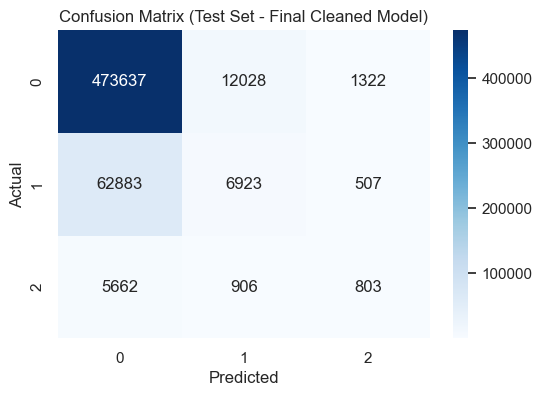

Classification Report (Test Set - Final Cleaned Model):
              precision    recall  f1-score   support

           1       0.87      0.97      0.92    486987
           2       0.35      0.10      0.15     70313
           3       0.31      0.11      0.16      7371

    accuracy                           0.85    564671
   macro avg       0.51      0.39      0.41    564671
weighted avg       0.80      0.85      0.82    564671

Accuracy: 0.8525
Accuracy: 85.25%


In [138]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y2_pred_clean = model_dt_clean_c.predict(X2_test_clean)

# Confusion Matrix
cm_test = confusion_matrix(y2_test_clean, y2_pred_clean)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set - Final Cleaned Model)")
plt.show()

# Classification Report
print("Classification Report (Test Set - Final Cleaned Model):")
print(classification_report(y2_test_clean, y2_pred_clean))

# Accuracy
accuracy = accuracy_score(y2_test_clean, y2_pred_clean)
print("Accuracy: {:.4f}".format(accuracy))
print("Accuracy: {:.2f}%".format(accuracy * 100))


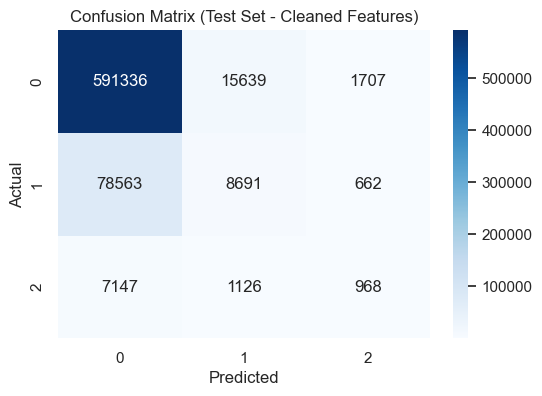

Classification Report (Test Set):
              precision    recall  f1-score   support

           1       0.87      0.97      0.92    608682
           2       0.34      0.10      0.15     87916
           3       0.29      0.10      0.15      9241

    accuracy                           0.85    705839
   macro avg       0.50      0.39      0.41    705839
weighted avg       0.80      0.85      0.81    705839

Accuracy: 0.8515
Accuracy: 85.15%


In [140]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Drop irrelevant columns
columns_to_drop = [
    "Accident_Severity",
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time",
    "Month",
    "Year",
    "Vehicle_Reference"
]

X2 = df.drop(columns=columns_to_drop)
y2 = df["Accident_Severity"]

# Step 2: One-hot encode
X2_encoded = pd.get_dummies(X2)

# Step 3: Drop all Day_of_Week_* dummy columns
day_of_week_cols = [col for col in X2_encoded.columns if col.startswith("Day_of_Week_")]
X2_encoded_clean = X2_encoded.drop(columns=day_of_week_cols)

# Step 4: Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X2_encoded_clean, y2, test_size=0.25, random_state=42
)

# Step 5: Train model
model_dt_clean_c = DecisionTreeClassifier(random_state=42)
model_dt_clean_c.fit(X_train_c, y_train_c)

# Step 6: Evaluate on test data
y_pred_c = model_dt_clean_c.predict(X_test_c)

# Step 7: Confusion matrix
cm = confusion_matrix(y_test_c, y_pred_c)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Test Set - Cleaned Features)")
plt.show()

# Step 8: Classification report and accuracy
print("Classification Report (Test Set):")
print(classification_report(y_test_c, y_pred_c))

accuracy = accuracy_score(y_test_c, y_pred_c)
print("Accuracy: {:.4f}".format(accuracy))
print("Accuracy: {:.2f}%".format(accuracy * 100))


Classification Report:
              precision    recall  f1-score   support

           1       0.87      0.97      0.92    608682
           2       0.34      0.10      0.15     87916
           3       0.29      0.10      0.15      9241

    accuracy                           0.85    705839
   macro avg       0.50      0.39      0.41    705839
weighted avg       0.80      0.85      0.81    705839

Accuracy: 85.15%


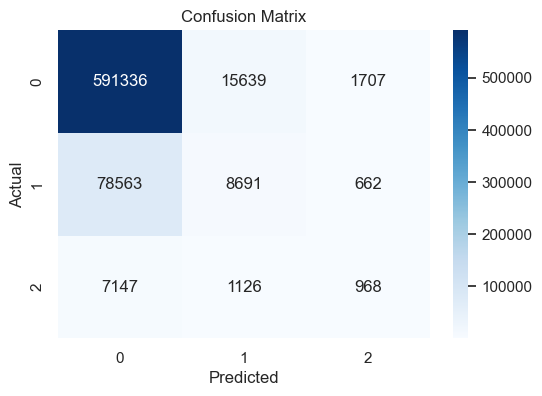


Top 10 Important Features:
                         Feature  Importance
2                           Hour    0.235253
0             Number_of_Vehicles    0.096462
6                    Speed_limit    0.094482
1           Number_of_Casualties    0.073417
7                   Vehicle_Type    0.066217
3               Light_Conditions    0.044553
9             WeekdayEnd_Weekend    0.027325
8             WeekdayEnd_Weekday    0.027089
33     Urban_or_Rural_Area_Rural    0.025225
31  Road_Type_TwoWayNonSeparated    0.022736


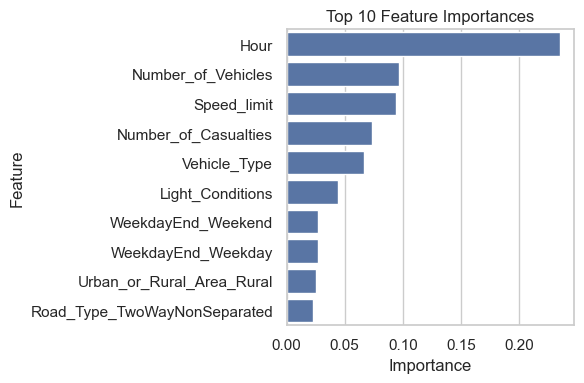

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Step 1: Drop irrelevant columns from original df
columns_to_drop = [
    "Accident_Severity2Category",
    "Accident_Severity3Category",
    "Accident_Index",
    "Date",
    "Time",
    "Month",
    "Year",
    "Vehicle_Reference"
]

X = df.drop(columns=columns_to_drop + ["Accident_Severity"])
y = df["Accident_Severity"]

# Step 2: One-hot encode
X_encoded = pd.get_dummies(X)

# Step 3: Drop Day_of_Week_* columns
day_of_week_cols = [col for col in X_encoded.columns if col.startswith("Day_of_Week_")]
X_encoded_clean = X_encoded.drop(columns=day_of_week_cols)

# Step 4: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded_clean, y, test_size=0.25, random_state=42)

# Step 5: Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)

# Classification Report & Accuracy
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))

# Step 7: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Step 8: Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_encoded_clean.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10))

# Optional: Barplot of top 10
plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()
